# 2. Data Understanding

Segunda fase do CRISP-DM. Aqui o objetivo é olhar para os dados pela primeira vez e responder a três perguntas práticas antes de pensar em qualquer modelo:

1. O dataset tem qualidade técnica suficiente para o trabalho? (tipos, missing, duplicatas)
2. As variáveis se comportam como o dicionário do PDF promete?
3. As 7 hipóteses formuladas no notebook 01 continuam viáveis com o que os dados realmente oferecem?

A ideia é separar o que precisa de tratamento (que vai para o notebook 03) do que está pronto para ser analisado direto. Vamos manter o tom narrativo: cada bloco de código vem acompanhado do raciocínio que motivou ele e da leitura do que ele produziu.

## 2.1 Carregamento e inspeção inicial

Antes de qualquer análise, três passos: carregar o CSV, conferir o formato e comparar o que veio com o que o dicionário do enunciado prometia. Se algo não bater (coluna a mais ou a menos, tipo errado, valor estranho), é melhor descobrir agora do que mais adiante.

Vou usar pandas como base, numpy para operações vetoriais, e configurar matplotlib e seaborn já no início do notebook para padronizar todas as figuras que aparecerem nas próximas seções.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reprodutibilidade — semente fixa para qualquer operação aleatória
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuração visual padrão (seaborn whitegrid + tamanho de figura legível)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Caminhos do projeto (relativos ao notebook em repo/notebooks/)
RAIZ_PROJETO = Path.cwd().parent
DADOS_BRUTOS = RAIZ_PROJETO / "data" / "raw" / "desafio_nps_fase_1.csv"
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "02_data_understanding"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carregamento da base
dados = pd.read_csv(DADOS_BRUTOS)

print(f"Linhas: {dados.shape[0]:,} | Colunas: {dados.shape[1]}")
print(f"Memória: {dados.memory_usage(deep=True).sum() / 1024:.1f} KB")

Linhas: 2,500 | Colunas: 19
Memória: 488.1 KB


O dicionário do enunciado lista 19 colunas, e o arquivo tem 2.500 linhas (uma linha por pedido, com `customer_id` repetindo quando o mesmo cliente fez mais de um pedido). A próxima checagem é olhar tipo de cada coluna para garantir que pandas interpretou tudo da forma esperada: variáveis numéricas como int ou float, e a região como string.

In [2]:
# Tipos de cada coluna e amostra das primeiras linhas
print("Tipos de dado por coluna:")
print(dados.dtypes.to_string())
print("\nPrimeiras linhas:")
dados.head(3)

Tipos de dado por coluna:
customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64

Primeiras linhas:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5


Os tipos vieram coerentes com o dicionário do PDF:

- **Identificadores e contagens** (`customer_id`, `order_id`, `customer_age`, `customer_tenure_months`, `items_quantity`, `payment_installments`, `delivery_time_days`, `delivery_delay_days`, `delivery_attempts`, `customer_service_contacts`, `resolution_time_days`, `complaints_count`, `repeat_purchase_30d`) vieram como `int64`. Faz sentido: são contagens e quantidades inteiras.
- **Valores monetários e scores** (`order_value`, `discount_value`, `freight_value`, `nps_score`, `csat_internal_score`) vieram como `float64`. Também coerente.
- **Região** (`customer_region`) veio como string. Vamos converter para categoria (`pd.Categorical`) lá no notebook 03, porque categoria ocupa menos memória e é mais rápida em comparações. Não é necessário fazer isso agora.

Um detalhe que vale comentar: o `nps_score` veio como `float`, com valores como 6.9, 2.4, 4.8 etc. O NPS canônico, definido por Reichheld em 2003, usa nota inteira de 0 a 10. Esse formato com decimais é incomum e merece investigação na seção 2.3, onde vamos olhar a distribuição da target em detalhe.

Antes de seguir, vale uma visão de alto nível das 19 variáveis: como elas se distribuem entre as áreas funcionais da operação. Isso ajuda a fixar mentalmente "onde mora cada coisa" antes de mergulhar nos detalhes.

Total de variáveis somadas: 19 (esperado: 19)


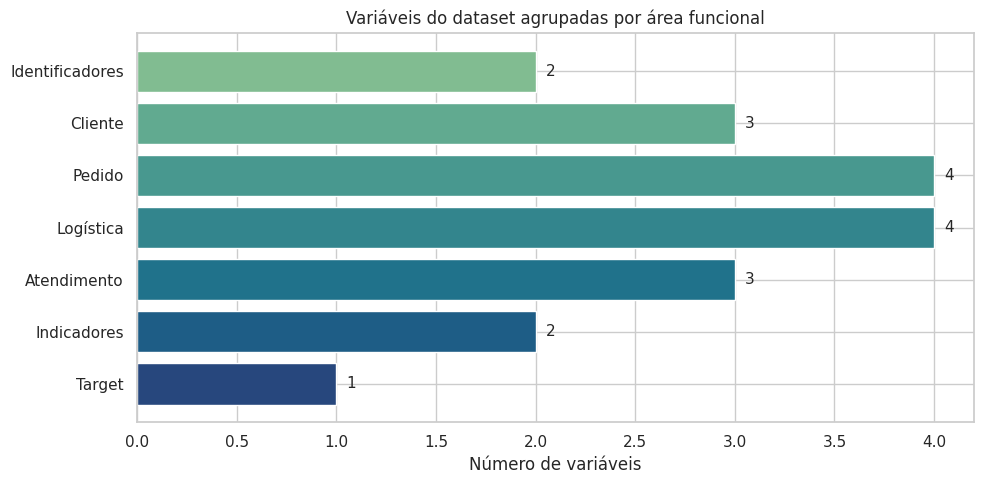

In [3]:
# Agrupamento das colunas por área funcional
grupos_colunas = {
    "Identificadores": ["customer_id", "order_id"],
    "Cliente":         ["customer_age", "customer_region", "customer_tenure_months"],
    "Pedido":          ["order_value", "items_quantity", "discount_value", "payment_installments"],
    "Logística":       ["delivery_time_days", "delivery_delay_days", "freight_value", "delivery_attempts"],
    "Atendimento":     ["customer_service_contacts", "resolution_time_days", "complaints_count"],
    "Indicadores":     ["repeat_purchase_30d", "csat_internal_score"],
    "Target":          ["nps_score"],
}

contagem_grupos = {nome: len(cols) for nome, cols in grupos_colunas.items()}

# Soma de checagem (deve dar 19)
total = sum(contagem_grupos.values())
print(f"Total de variáveis somadas: {total} (esperado: {dados.shape[1]})")

# Bar chart horizontal das categorias
fig, eixo = plt.subplots(figsize=(10, 5))
nomes = list(contagem_grupos.keys())
valores = list(contagem_grupos.values())

cores_grupos = sns.color_palette("crest", n_colors=len(nomes))
barras = eixo.barh(nomes, valores, color=cores_grupos)
for i, v in enumerate(valores):
    eixo.text(v + 0.05, i, str(v), va="center", fontsize=11)

eixo.set_xlabel("Número de variáveis")
eixo.set_title("Variáveis do dataset agrupadas por área funcional")
eixo.invert_yaxis()
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_1_perfil_variaveis_por_area.png", dpi=120, bbox_inches="tight")
plt.show()

![Variáveis do dataset agrupadas por área funcional](../reports/figures/02_data_understanding/2_1_perfil_variaveis_por_area.png)

**Como ler este gráfico:** cada barra horizontal representa uma área funcional do dataset (Identificadores, Cliente, Pedido, Logística, Atendimento, Indicadores, Target). O comprimento da barra mostra **quantas variáveis** pertencem àquela área. O número à direita de cada barra é a contagem exata. A ordem segue do mais geral (identificadores) para o mais específico (target).

## 2.2 Qualidade técnica

Antes de qualquer análise mais profunda, vale checar três coisas básicas: se há valores faltantes, se há linhas duplicadas, e qual é a granularidade real do dataset (uma linha equivale a um pedido, a um cliente, ou a algo intermediário?). Essas três checagens definem o que precisa de tratamento no notebook 03 e o que já está pronto para usar.

In [4]:
# Quantos valores faltantes em cada coluna
print("Valores faltantes por coluna:")
print(dados.isna().sum().to_string())
print(f"\nTotal de missing no dataset: {dados.isna().sum().sum()}")

Valores faltantes por coluna:
customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0

Total de missing no dataset: 0


Zero valores faltantes em qualquer coluna. Isso é incomum em datasets reais de e-commerce: normalmente alguma coluna sofre com falha de coleta, integração entre sistemas ou cliente que não preencheu campo. Aqui não tem nada disso.

A leitura mais provável é que o dataset foi pré-tratado para o exercício, ou foi gerado de forma sintética. Para o trabalho, isso simplifica bastante: não vamos gastar tempo com imputação ou estratégia de tratamento de missing no notebook 03. Mas é importante registrar que essa "limpeza perfeita" é uma característica do dataset acadêmico, e na prática a empresa real precisaria lidar com missing.

In [5]:
# Linhas inteiramente duplicadas
linhas_duplicadas = dados.duplicated().sum()
print(f"Linhas duplicadas (todas as colunas iguais): {linhas_duplicadas}")

# Unicidade dos identificadores
print(f"\norder_id únicos:    {dados['order_id'].nunique():,} de {len(dados):,} linhas")
print(f"customer_id únicos: {dados['customer_id'].nunique():,} de {len(dados):,} linhas")

# Distribuição de pedidos por cliente
pedidos_por_cliente = dados['customer_id'].value_counts()
print(f"\nDistribuição de pedidos por cliente:")
print(pedidos_por_cliente.value_counts().sort_index().to_string())

Linhas duplicadas (todas as colunas iguais): 0

order_id únicos:    2,500 de 2,500 linhas
customer_id únicos: 2,500 de 2,500 linhas

Distribuição de pedidos por cliente:
count
1    2500


Três achados importantes nessa célula:

1. **Nenhuma linha duplicada.** Cada registro é único, sem repetição idêntica.
2. **Cada `order_id` aparece uma vez.** Os 2.500 pedidos são todos distintos.
3. **Cada `customer_id` aparece uma vez.** São 2.500 clientes diferentes, cada um com exatamente um pedido.

O terceiro ponto é o mais relevante para a análise. O dataset não é um histórico longitudinal (cliente comprando várias vezes ao longo do tempo): é um snapshot de pedidos, onde cada cliente entra com uma única observação. Isso tem três implicações práticas:

- **Granularidade da análise:** linha = pedido = cliente. Não precisamos de agregação por cliente; cada estatística que calcularmos no nível do pedido é também a estatística no nível do cliente.
- **Variável `customer_tenure_months`:** descreve o tempo de relacionamento do cliente com a empresa, mas só temos uma foto desse cliente. Não dá para analisar como a satisfação dele variou conforme o tenure cresceu. Tenure é uma característica fixa do cliente nesta base, não uma trajetória.
- **Hipótese H5 (NPS prediz recompra):** o `repeat_purchase_30d` é uma variável binária que indica se o cliente comprou de novo em até 30 dias depois deste pedido. A próxima compra existe no mundo real, mas não está no dataset; só temos o flag de que ela ocorreu (1) ou não (0). Para a hipótese H5 isso é suficiente, basta cruzar `nps_score` com `repeat_purchase_30d`.

Como a checagem de missing deu zero em todas as colunas, vale também uma confirmação visual. Em datasets reais, esse gráfico costuma mostrar faixas de "buracos" claros indicando onde a coleta falhou. Aqui o mapa vai aparecer todo preenchido.

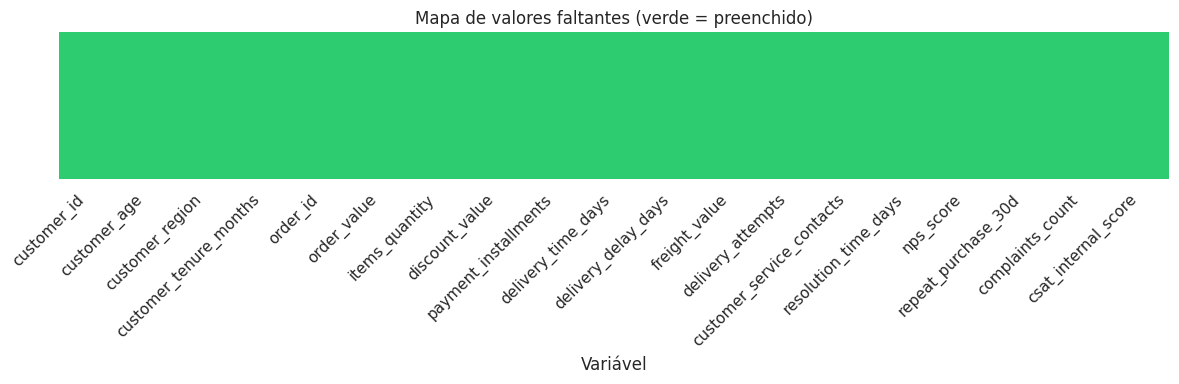

In [6]:
# Mapa visual de valores faltantes
fig, eixo = plt.subplots(figsize=(12, 4))
mascara_missing = dados.isna()
sns.heatmap(
    mascara_missing,
    cbar=False,
    cmap=["#2ecc71"],
    yticklabels=False,
    ax=eixo,
)
eixo.set_title("Mapa de valores faltantes (verde = preenchido)")
eixo.set_xlabel("Variável")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_2_mapa_missing.png", dpi=120, bbox_inches="tight")
plt.show()

![Mapa de valores faltantes — todas as células preenchidas](../reports/figures/02_data_understanding/2_2_mapa_missing.png)

**Como ler este gráfico:** o eixo X lista todas as 19 variáveis do dataset; o eixo Y representa as 2.500 linhas (sem rótulos individuais, é uma faixa contínua). Cada célula do mapa seria branca se houvesse um valor faltante naquele cruzamento. Como **a figura inteira está pintada de verde**, não há nenhum valor faltante em todo o dataset.

## 2.3 A target — `nps_score`

A variável que vamos prever merece olhar separado. Na seção 2.1 chamou atenção que o `nps_score` veio como `float`, com valores como 6.9 e 4.8, em vez do inteiro de 0 a 10 que o NPS canônico usa. Antes de qualquer modelo, faz sentido entender três coisas: quais são os valores observados na prática, como eles se distribuem, e o que isso significa para a estratégia de modelagem (regressão na escala contínua vs. classificação nos buckets canônicos).

In [7]:
# Estatísticas descritivas da target
print("Descritivas de nps_score:")
print(dados["nps_score"].describe().round(3).to_string())

print(f"\nValores únicos observados: {dados['nps_score'].nunique()}")
print(f"Mínimo: {dados['nps_score'].min()}")
print(f"Máximo: {dados['nps_score'].max()}")

Descritivas de nps_score:
count    2500.000
mean        4.379
std         2.510
min         0.000
25%         2.600
50%         4.400
75%         6.100
max        10.000

Valores únicos observados: 101
Mínimo: 0.0
Máximo: 10.0


Três achados nessa célula valem destaque.

**A escala vai de 0.0 a 10.0, mas com 101 valores únicos.** Isso sugere que a nota foi arredondada para uma casa decimal, gerando exatamente 101 pontos possíveis (0.0, 0.1, 0.2, ..., 9.9, 10.0). Não é a escala canônica do NPS (inteiro de 0 a 10), e também não é uma medida totalmente contínua. É algo intermediário, e o motivo provável é que esse score deriva de alguma agregação ou cálculo interno da empresa.

**A média é 4.38 e a mediana é 4.4.** Isso é bastante baixo. Numa escala de 0 a 10, valores ao redor de 4 indicam que a nota típica do cliente está mais próxima do extremo "não recomendaria" do que do extremo "recomendaria com entusiasmo".

**A distribuição é assimétrica.** Os quartis (2.6 / 4.4 / 6.1) mostram que três quartos dos clientes deram nota até 6.1. A maior parte da massa está concentrada na metade de baixo da escala, o que reforça a impressão de empresa com problemas sérios de satisfação.

A próxima célula vai categorizar essas notas nos buckets canônicos (detrator, neutro, promotor) para ver de forma mais clara quem são os clientes da empresa.

Distribuição da target nos buckets canônicos:
  detrator : 2,109 (84.4%)
  neutro   :   281 (11.2%)
  promotor :   110 (4.4%)

NPS bruto da empresa = % promotores - % detratores = -80.0


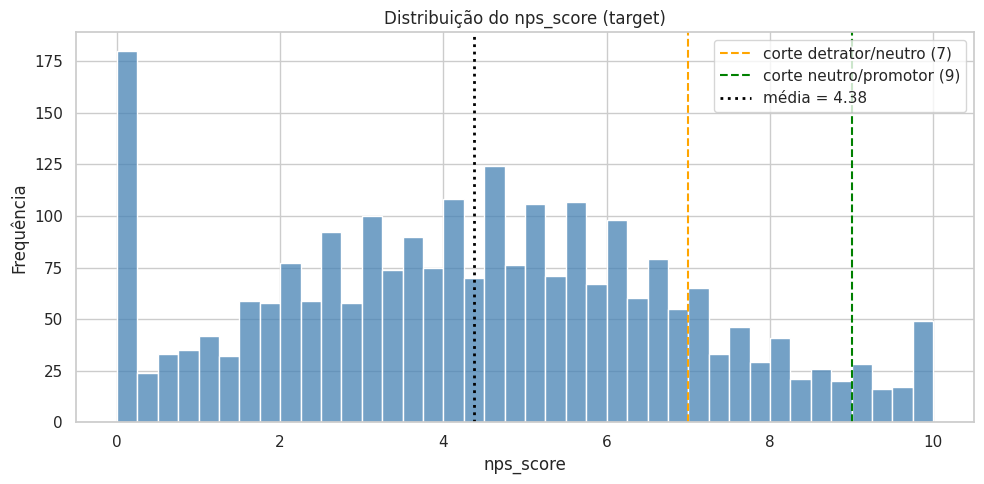

In [8]:
# Categorização nos buckets canônicos do NPS
def classificar_nps(nota: float) -> str:
    """Aplica a regra canônica do NPS: detrator (0-6), neutro (7-8), promotor (9-10).

    Como o nps_score está em float, usamos < 7 e < 9 como cortes para preservar
    a regra clássica (cliente com 6.9 ainda é detrator; com 7.0 vira neutro).
    """
    if nota < 7:
        return "detrator"
    elif nota < 9:
        return "neutro"
    else:
        return "promotor"

categorias = dados["nps_score"].apply(classificar_nps)
contagem = categorias.value_counts()
percentual = categorias.value_counts(normalize=True) * 100

# Ordenação fixa para leitura (detrator, neutro, promotor)
ordem = ["detrator", "neutro", "promotor"]
print("Distribuição da target nos buckets canônicos:")
for cat in ordem:
    n = contagem.get(cat, 0)
    p = percentual.get(cat, 0)
    print(f"  {cat:9s}: {n:5,} ({p:.1f}%)")

# NPS bruto: % promotores - % detratores
nps_bruto = percentual.get("promotor", 0) - percentual.get("detrator", 0)
print(f"\nNPS bruto da empresa = % promotores - % detratores = {nps_bruto:.1f}")

# Histograma da target com linhas verticais marcando os cortes canônicos e a média
media_nps = dados["nps_score"].mean()
fig, eixo = plt.subplots(figsize=(10, 5))
sns.histplot(data=dados, x="nps_score", bins=40, ax=eixo, color="steelblue", edgecolor="white")
eixo.axvline(7, color="orange", linestyle="--", label="corte detrator/neutro (7)")
eixo.axvline(9, color="green", linestyle="--", label="corte neutro/promotor (9)")
eixo.axvline(media_nps, color="black", linestyle=":", linewidth=2, label=f"média = {media_nps:.2f}")
eixo.set_title("Distribuição do nps_score (target)")
eixo.set_xlabel("nps_score")
eixo.set_ylabel("Frequência")
eixo.legend()
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_3_distribuicao_nps_score.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuição do nps_score com cortes canônicos](../reports/figures/02_data_understanding/2_3_distribuicao_nps_score.png)

**Como ler este gráfico:** o eixo X é a nota de NPS (0 a 10) e o eixo Y é o número de clientes que receberam aquela nota. As **linhas tracejadas verticais** marcam os cortes canônicos do NPS: laranja em 7 separa detrator de neutro; verde em 9 separa neutro de promotor. A **linha pontilhada preta** marca a média da distribuição. Um histograma puxado para a esquerda significa que a maior parte das notas é baixa.

A categorização confirma um cenário difícil para a empresa.

- **2.109 clientes (84,4%) são detratores.**
- **281 clientes (11,2%) são neutros.**
- **Apenas 110 clientes (4,4%) são promotores.**

O NPS bruto calculado (proporção de promotores menos proporção de detratores) fica em **-80**. Para referência, o e-commerce brasileiro tipicamente roda em torno de +50 ([Retently NPS benchmarks](https://retently.com/blog/good-net-promoter-score/)). Um NPS de -80 não é apenas ruim, é catastrófico para uma empresa real.

Esse número é tão extremo que cabe levantar uma hipótese: o dataset provavelmente foi construído de forma sintética para o exercício, com distribuição enviesada para detratores deliberadamente, para deixar o problema didático mais interessante. Para o trabalho acadêmico, isso não invalida nada da análise, mas é uma observação que precisa estar nas limitações: as conclusões sobre fatores que explicam detração continuam válidas como exercício metodológico, mas os números absolutos não devem ser interpretados como benchmark de mercado.

Três implicações práticas que vão guiar as próximas fases.

**Para regressão (notebook 05):** o `nps_score` em float dá granularidade fina (101 valores possíveis). É a representação mais informativa, e regressão linear vai conseguir captar variações sutis na nota a partir das variáveis operacionais.

**Para classificação (notebook 06):** o desbalanceamento é forte. Detratores dominam a base (84,4%), e qualquer modelo ingênuo vai tender a "chutar detrator" para todo mundo e parecer ter acurácia de 84%. Vamos precisar de cuidado especial: trabalhar com `class_weight` balanceado, ou olhar métricas além de acurácia (precision/recall por classe), ou redefinir o problema como binário (detrator vs. não-detrator) para simplificar.

**Para o storytelling executivo:** o número absoluto do NPS bruto (-80) é forte demais para passar despercebido no slide. Vou usar o desbalanceamento da base para reforçar o argumento de urgência: a empresa não tem só um problema de NPS, ela tem um problema sistêmico, e o modelo preditivo é parte da resposta.

Os números absolutos são úteis, mas a desproporção entre as três categorias fica mais clara em um gráfico. Vou usar cores semânticas (vermelho para detrator, cinza para neutro, verde para promotor), porque elas vão se repetir nos slides executivos depois.

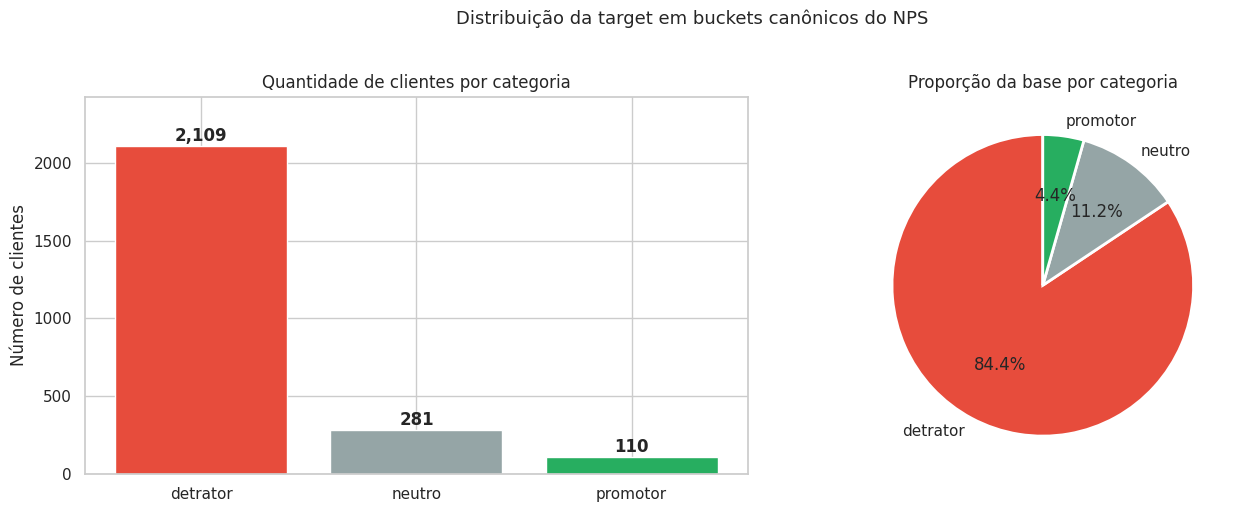

In [9]:
# Cores semânticas que vamos manter consistentes em todo o trabalho
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}

# Recalcula categorias localmente (independência da célula anterior)
def classificar_nps(nota: float) -> str:
    if nota < 7:
        return "detrator"
    elif nota < 9:
        return "neutro"
    else:
        return "promotor"

categorias_nps = dados["nps_score"].apply(classificar_nps)
ordem_buckets = ["detrator", "neutro", "promotor"]
contagem_buckets = categorias_nps.value_counts().reindex(ordem_buckets)
percentual_buckets = categorias_nps.value_counts(normalize=True).reindex(ordem_buckets) * 100

# Dois gráficos lado a lado: contagem absoluta + proporção
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: contagem absoluta
cores_ord = [cores_buckets[c] for c in ordem_buckets]
eixos[0].bar(ordem_buckets, contagem_buckets.values, color=cores_ord, edgecolor="white")
for i, v in enumerate(contagem_buckets.values):
    eixos[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=12, fontweight="bold")
eixos[0].set_title("Quantidade de clientes por categoria")
eixos[0].set_ylabel("Número de clientes")
eixos[0].set_ylim(0, contagem_buckets.max() * 1.15)

# Direita: pizza com proporção
eixos[1].pie(
    percentual_buckets.values,
    labels=ordem_buckets,
    autopct="%1.1f%%",
    colors=cores_ord,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
eixos[1].set_title("Proporção da base por categoria")

fig.suptitle("Distribuição da target em buckets canônicos do NPS", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_3_categorias_buckets.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuição da target em buckets canônicos do NPS](../reports/figures/02_data_understanding/2_3_categorias_buckets.png)

**Como ler este gráfico:** dois painéis com a mesma informação em formatos diferentes. À esquerda, um **bar chart** com a quantidade absoluta de clientes em cada categoria, com o número exato anotado em cima de cada barra. À direita, um **gráfico de pizza** com as proporções percentuais. As cores são semânticas e vão se repetir em todo o trabalho: **vermelho = detrator, cinza = neutro, verde = promotor**.

## 2.4 Definição formal da target

Esta seção fecha o Bloco 2 do enunciado, respondendo de forma estruturada as quatro perguntas que ele faz sobre a variável-alvo. A discussão conceitual já apareceu nas seções 1.2 e 1.7; aqui está formalizada num único lugar para facilitar referência.

### Qual variável representa a satisfação do cliente?

A variável escolhida é o **`nps_score`**, observada em escala 0 a 10, com arredondamento para uma casa decimal (101 valores possíveis na prática). Ela está disponível para todos os 2.500 pedidos do dataset, sem valores faltantes, e é a única coluna que captura intenção declarada de recomendação por parte do cliente.

### Por que ela foi escolhida?

A escolha do `nps_score` como target não é trivial, considerando que o dataset oferece outras candidatas plausíveis (`csat_internal_score`, `repeat_purchase_30d`, `complaints_count`). Quatro razões justificam a preferência pelo NPS, todas já discutidas com profundidade na seção 1.2.

A primeira é que o NPS mede **vínculo atitudinal** com a marca, não um evento específico da jornada. CSAT é episódico (avaliação de uma transação), recompra é comportamental (registra um ato), reclamação é autosselecionada (só capta quem se manifesta). NPS pergunta diretamente sobre a disposição do cliente em recomendar, o que é proxy mais direto de fidelidade futura.

A segunda é que o NPS captura o **detrator silencioso**, o cliente que ficou insatisfeito mas não reclamou. As outras métricas internas tendem a perder esse perfil, e ele tipicamente representa a maior parte da insatisfação real.

A terceira é que o NPS é **comparável entre empresas e setores**. Existem benchmarks públicos (como os do Retently citado na 1.5) que permitem situar o desempenho da empresa contra o mercado. CSAT interno e métricas comportamentais não são facilmente comparáveis dessa forma.

A quarta razão é objetiva: o enunciado define o `nps_score` como target oficial. Mas as três anteriores explicam por que essa escolha do enunciado faz sentido analiticamente, e não é só convenção.

### Em que momento da jornada essa informação é coletada?

O `nps_score` é coletado **após o encerramento da jornada de compra**, normalmente via pesquisa por e-mail ou dentro do app, depois que o cliente recebeu o pedido e teve as eventuais interações pós-venda com o atendimento. Esse posicionamento temporal é justamente o que motiva o projeto: a empresa só descobre que tem um detrator quando ele já está detratando.

Em vocabulário de monitoramento, é um *lagging indicator* puro. Toda a estratégia do trabalho é construir um modelo que use as variáveis operacionais coletadas **durante** a jornada (entrega, atendimento, perfil do pedido) como *leading indicators*, antecipando o NPS antes da pesquisa.

### Existe risco de usar essa variável de forma inadequada?

Sim, e o trabalho precisa estar consciente de pelo menos cinco riscos.

**Risco 1: target leakage com `csat_internal_score`.** Como já discutido na 1.7, é provável que o `csat_internal_score` tenha sido calculado pela empresa a partir das mesmas variáveis operacionais que vamos usar como entrada do modelo. Incluir essa variável no modelo pode dar uma falsa sensação de qualidade. A mitigação é rodar o modelo com e sem o `csat_internal_score` e comparar.

**Risco 2: ignorar o desbalanceamento.** A distribuição observada na 2.3 mostra 84,4% de detratores, 11,2% de neutros e 4,4% de promotores. Tratar essa base como balanceada na fase de classificação levaria a um modelo que "chuta detrator" para todo mundo e parece bom em acurácia, mas é inútil para o negócio. A mitigação envolve usar `class_weight` balanceado, considerar reformulação binária do problema (detrator vs. não-detrator), e sempre olhar métricas além de acurácia (precision e recall por classe).

**Risco 3: tratar o NPS bruto -80 da empresa como benchmark realista.** Esse número é muito mais baixo do que qualquer e-commerce real costuma ter, e provavelmente reflete um dataset sintético construído para o exercício. Conclusões que dependam do **valor absoluto** do NPS (do tipo "a empresa está em situação crítica") precisam vir acompanhadas dessa ressalva. Conclusões sobre **fatores relativos** (do tipo "atraso na entrega derruba o NPS em X") são robustas, porque dependem de relação entre variáveis e não do nível absoluto.

**Risco 4: confundir representação contínua com representação categórica.** O `nps_score` é float (0.0 a 10.0 em passos de 0.1). Pode ser usado como variável contínua (regressão) ou como variável categórica de três classes (classificação). Cada representação responde a uma pergunta diferente: regressão preserva nuance ("quão detrator é?"), classificação simplifica para o uso prático ("qual ação tomar?"). O trabalho vai rodar as duas, conforme já acordado na seção 1.6, mas é importante não misturar os contextos: comparar RMSE de regressão com acurácia de classificação não faz sentido.

**Risco 5: confundir correlação com causalidade.** O modelo vai mostrar quais variáveis estão associadas a NPS mais baixo. Isso não significa, automaticamente, que mexer nessas variáveis vai melhorar o NPS. Algumas relações podem ser sintoma e não causa, como já levantado na 1.7 sobre `customer_service_contacts`. As recomendações de negócio precisam ser feitas com cuidado interpretativo, separando o que é provavelmente causa do que é provavelmente efeito.

## 2.5 Perfil das variáveis numéricas

Agora que conhecemos a target, vale fazer um raio-X das outras 14 variáveis numéricas, agrupadas pelas áreas funcionais que mapeamos na 2.1. O objetivo é entender três coisas para cada grupo: que ranges os valores assumem, como a distribuição se comporta (simétrica, assimétrica, concentrada), e se aparece algo estranho (valores impossíveis, picos suspeitos, ranges fora do esperado pelo dicionário).

A discussão fica em estatística descritiva pura. Análises de relação entre variáveis e a target ficam para a EDA do notebook 04.

Estatísticas descritivas — Cliente:
       customer_age  customer_tenure_months
count       2500.00                 2500.00
mean          43.40                   61.32
std           14.89                   34.48
min           18.00                    1.00
25%           31.00                   31.00
50%           43.00                   62.00
75%           56.00                   91.00
max           69.00                  119.00


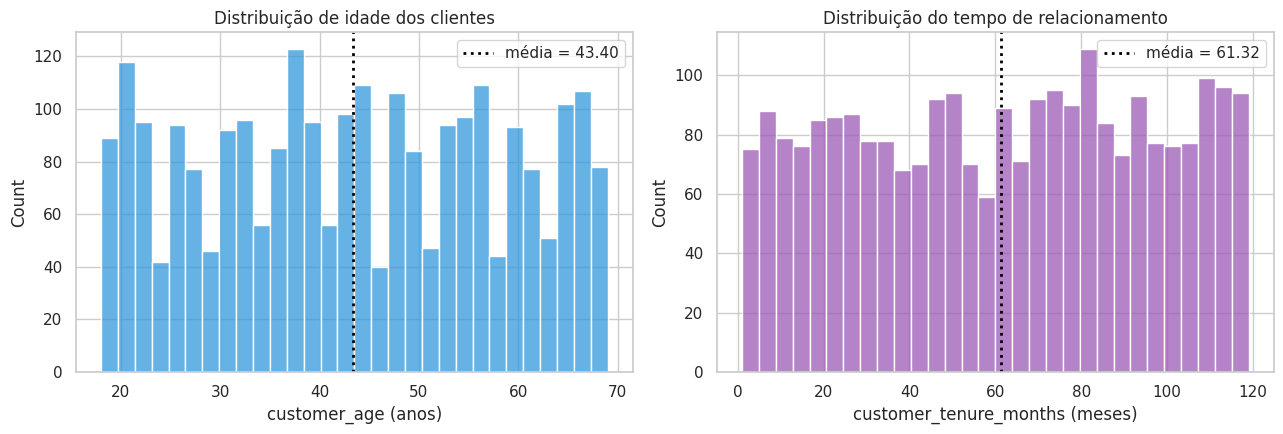

In [10]:
# Variáveis de perfil do cliente
variaveis_cliente = ["customer_age", "customer_tenure_months"]
print("Estatísticas descritivas — Cliente:")
print(dados[variaveis_cliente].describe().round(2).to_string())

# Histogramas lado a lado, com linha vertical na média
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))

configs = [
    ("customer_age",            "Distribuição de idade dos clientes",      "customer_age (anos)",       "#3498db"),
    ("customer_tenure_months",  "Distribuição do tempo de relacionamento", "customer_tenure_months (meses)", "#9b59b6"),
]

for eixo, (col, titulo, xlabel, cor) in zip(eixos, configs):
    sns.histplot(data=dados, x=col, bins=30, ax=eixo, color=cor, edgecolor="white")
    media = dados[col].mean()
    eixo.axvline(media, color="black", linestyle=":", linewidth=2, label=f"média = {media:.2f}")
    eixo.set_title(titulo)
    eixo.set_xlabel(xlabel)
    eixo.legend()

fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_5_cliente_distribuicoes.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuições de idade e tempo de relacionamento dos clientes](../reports/figures/02_data_understanding/2_5_cliente_distribuicoes.png)

**Como ler este gráfico:** dois histogramas lado a lado, um para cada variável de perfil do cliente. Em cada subplot, o eixo X é o valor da variável e o eixo Y é o número de clientes naquele intervalo. A **linha pontilhada preta vertical** marca a média da distribuição.

Os dois gráficos mostram distribuições praticamente uniformes.

A idade vai de 18 a 69 anos, com média e mediana ambas em torno de 43, e o histograma é razoavelmente plano (não há concentração em uma faixa etária específica). O tempo de relacionamento varia de 1 a 119 meses (quase 10 anos), também sem concentração clara.

Esse comportamento "uniforme demais" das duas variáveis é mais um sinal de que o dataset foi gerado de forma sintética, com valores sorteados aleatoriamente em ranges fixos. Em base real, a idade dos compradores online costuma ter pico entre 25 e 40 anos, e o tempo de relacionamento costuma ter cauda direita (maioria recente, alguns muito antigos). Para a análise, isso não invalida nada: significa apenas que `customer_age` e `customer_tenure_months` provavelmente vão entrar como variáveis com efeito relativamente fraco no modelo, porque elas não têm relação natural com NPS no jeito como foram geradas aqui.

Estatísticas descritivas — Pedido:
       order_value  items_quantity  discount_value  payment_installments
count      2500.00         2500.00         2500.00               2500.00
mean        434.26            3.47           29.75                  6.00
std         289.77            1.69           29.23                  3.16
min           7.76            1.00            0.02                  1.00
25%         220.24            2.00            8.88                  3.00
50%         375.52            3.00           20.94                  6.00
75%         577.29            5.00           40.83                  9.00
max        1983.81            6.00          230.33                 11.00


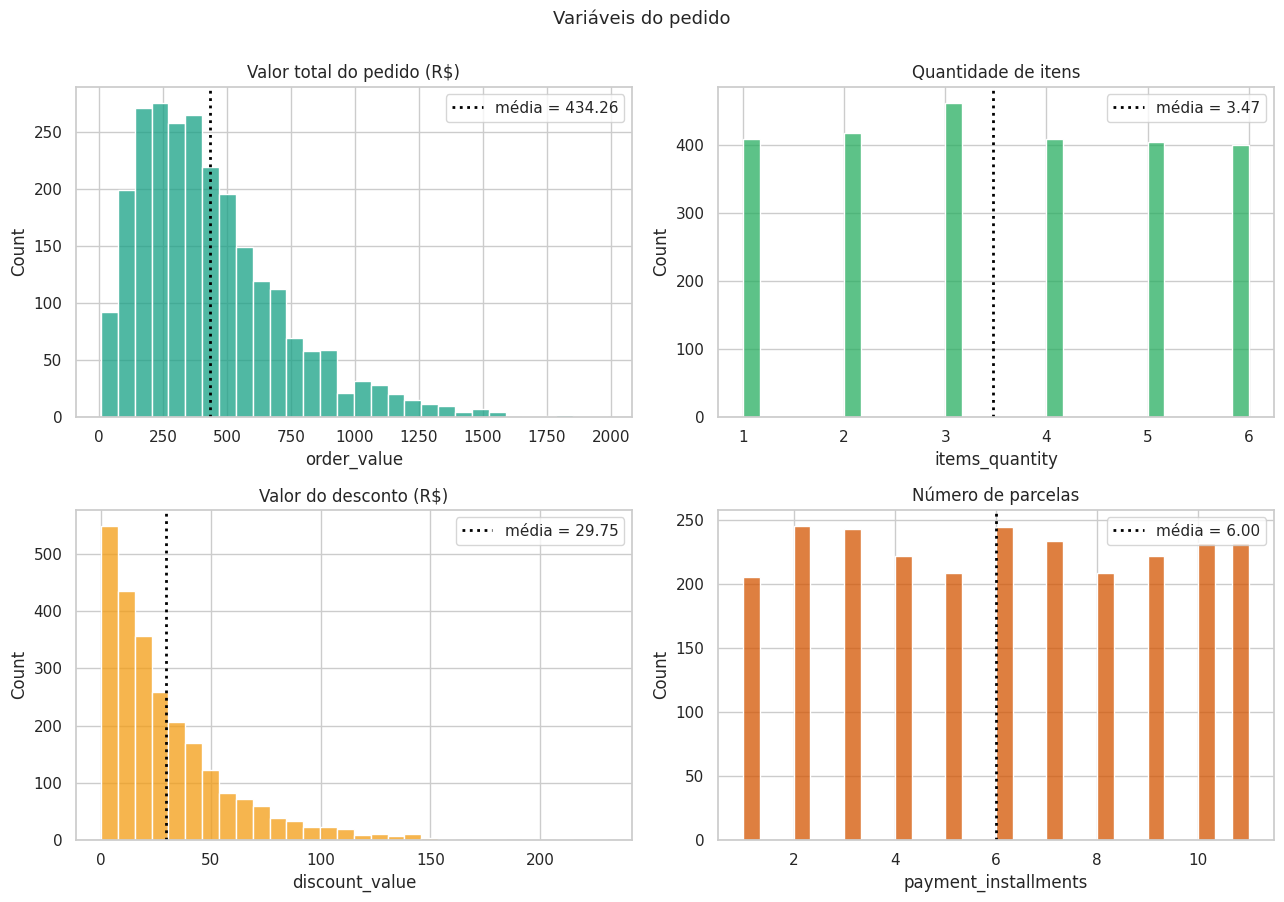

In [11]:
# Variáveis do pedido
variaveis_pedido = ["order_value", "items_quantity", "discount_value", "payment_installments"]
print("Estatísticas descritivas — Pedido:")
print(dados[variaveis_pedido].describe().round(2).to_string())

# Grid 2x2 de histogramas com linha de média
fig, eixos = plt.subplots(2, 2, figsize=(13, 9))
configs = [
    ("order_value",          "Valor total do pedido (R$)",        "#16a085"),
    ("items_quantity",       "Quantidade de itens",               "#27ae60"),
    ("discount_value",       "Valor do desconto (R$)",            "#f39c12"),
    ("payment_installments", "Número de parcelas",                "#d35400"),
]

for eixo, (col, titulo, cor) in zip(eixos.flat, configs):
    sns.histplot(data=dados, x=col, bins=30, ax=eixo, color=cor, edgecolor="white")
    media = dados[col].mean()
    eixo.axvline(media, color="black", linestyle=":", linewidth=2, label=f"média = {media:.2f}")
    eixo.set_title(titulo)
    eixo.set_xlabel(col)
    eixo.legend()

fig.suptitle("Variáveis do pedido", fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_5_pedido_distribuicoes.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuições das variáveis do pedido (valor, itens, desconto, parcelas)](../reports/figures/02_data_understanding/2_5_pedido_distribuicoes.png)

**Como ler este gráfico:** quatro histogramas em grid 2×2, um para cada variável do pedido. Em cada subplot, o eixo X é o valor da variável (em R$ ou contagem, conforme o caso) e o eixo Y é o número de pedidos naquele intervalo. A **linha pontilhada preta vertical** marca a média.

As quatro variáveis do pedido têm comportamentos distintos.

O `order_value` (valor do pedido) varia de R$ 7,76 a R$ 1.983,81, com média de R$ 434 e mediana de R$ 375. A distribuição é assimétrica à direita: a maior parte dos pedidos é de ticket médio-baixo, com cauda de pedidos mais caros se estendendo até quase R$ 2.000. Esse perfil é compatível com e-commerce de massa.

O `items_quantity` vai de 1 a 6 itens, distribuição relativamente plana com pico em 1-3 itens. Faz sentido como dado real.

O `discount_value` tem range de R$ 0,02 a R$ 230, média R$ 29,75. Também assimétrica à direita: muitos pedidos com desconto pequeno, alguns com desconto maior. Curioso que o mínimo seja 0,02 e não exatamente zero, o que sugere que todos os pedidos receberam algum desconto, mesmo que mínimo.

O `payment_installments` vai de 1 a 11 parcelas, distribuição uniforme. Para o varejo brasileiro, ter parcelamento até 11x é comum.

Esses ranges são todos plausíveis. Não há valores impossíveis (negativos, fora de escala) nem outliers extremos que mereçam tratamento agora.

Estatísticas descritivas — Logística:
       delivery_time_days  delivery_delay_days  freight_value  delivery_attempts
count             2500.00              2500.00        2500.00            2500.00
mean                 8.02                 2.19          38.22               2.01
std                  3.77                 1.45          12.08               0.82
min                  2.00                 0.00           2.62               1.00
25%                  5.00                 1.00          29.93               1.00
50%                  8.00                 2.00          38.50               2.00
75%                 11.00                 3.00          46.27               3.00
max                 14.00                 8.00          76.13               3.00


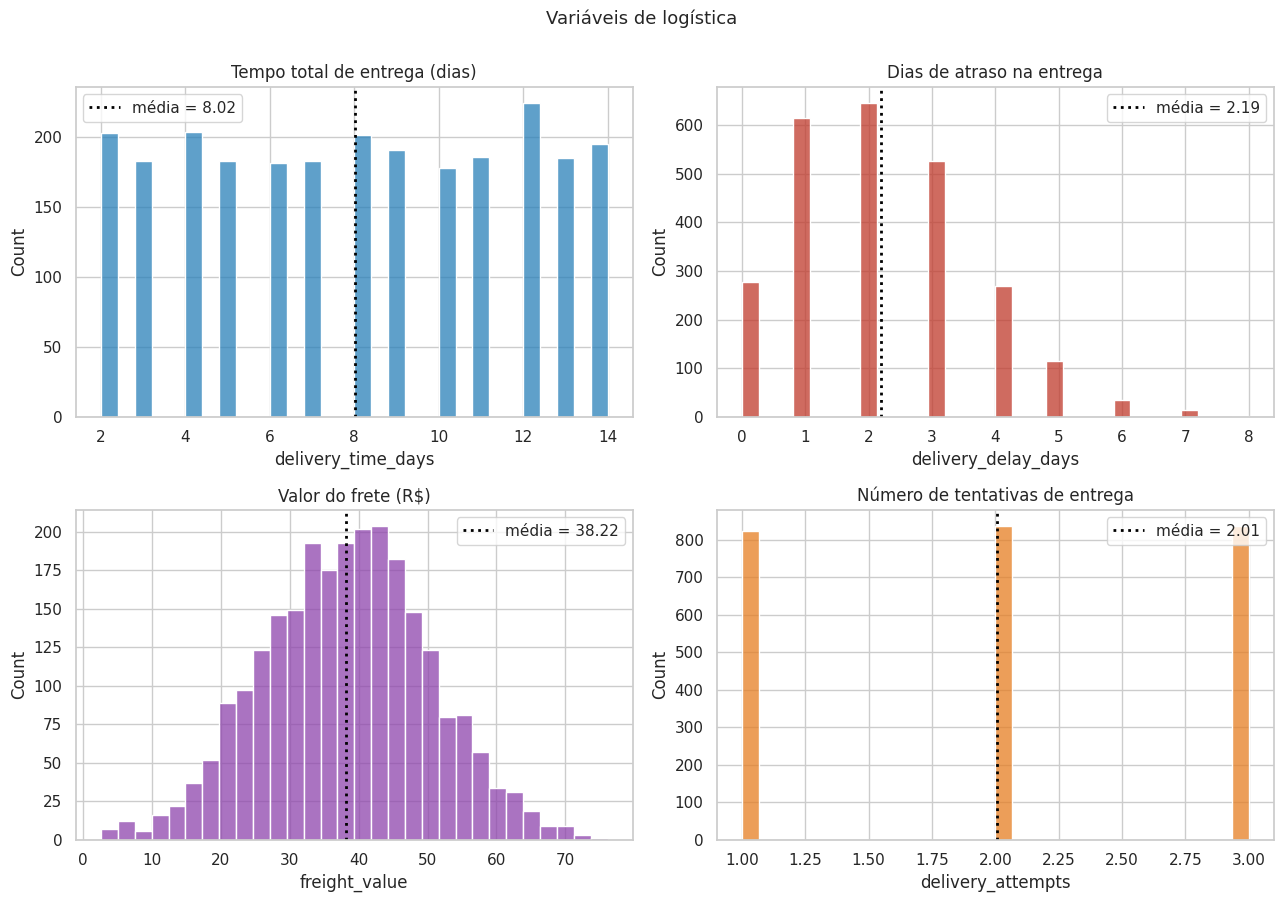

In [12]:
# Variáveis de logística
variaveis_logistica = ["delivery_time_days", "delivery_delay_days", "freight_value", "delivery_attempts"]
print("Estatísticas descritivas — Logística:")
print(dados[variaveis_logistica].describe().round(2).to_string())

# Grid 2x2 com linha de média em cada
fig, eixos = plt.subplots(2, 2, figsize=(13, 9))
configs = [
    ("delivery_time_days",  "Tempo total de entrega (dias)",   "#2980b9"),
    ("delivery_delay_days", "Dias de atraso na entrega",       "#c0392b"),
    ("freight_value",       "Valor do frete (R$)",             "#8e44ad"),
    ("delivery_attempts",   "Número de tentativas de entrega", "#e67e22"),
]

for eixo, (col, titulo, cor) in zip(eixos.flat, configs):
    sns.histplot(data=dados, x=col, bins=30, ax=eixo, color=cor, edgecolor="white")
    media = dados[col].mean()
    eixo.axvline(media, color="black", linestyle=":", linewidth=2, label=f"média = {media:.2f}")
    eixo.set_title(titulo)
    eixo.set_xlabel(col)
    eixo.legend()

fig.suptitle("Variáveis de logística", fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_5_logistica_distribuicoes.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuições das variáveis de logística (tempo, atraso, frete, tentativas)](../reports/figures/02_data_understanding/2_5_logistica_distribuicoes.png)

**Como ler este gráfico:** quatro histogramas em grid 2×2, um para cada variável logística (tempo de entrega, atraso, frete, tentativas). Em cada subplot, o eixo X é o valor da variável e o eixo Y é o número de pedidos. A **linha pontilhada preta vertical** marca a média.

Os números de logística trazem o achado mais relevante desta seção.

O `delivery_time_days` (tempo total de entrega) varia de 2 a 14 dias, média 8 e mediana 8. Esse range é razoável para e-commerce brasileiro fora dos hubs urbanos, embora a mediana de 8 dias seja considerada lenta para padrões atuais (Amazon Prime, Mercado Livre Full entregam em 1 a 3 dias).

O `delivery_delay_days` é o que chama mais atenção: varia de 0 a 8 dias, com **mediana 2 e média 2,19**. Isso significa que a maioria dos pedidos tem algum atraso — não é uma minoria afetada, é praticamente toda a base. Apenas o quartil inferior tem atraso de 1 dia ou menos. É outro sinal de que o dataset foi construído para o exercício pesar a mão na variável de atraso, deixando o problema de NPS mais "visível" para a modelagem.

O `freight_value` vai de R$ 2,62 a R$ 76, com média R$ 38, distribuição razoavelmente simétrica. Sem surpresas.

O `delivery_attempts` é uma variável discreta de 1 a 3, com média 2. Provavelmente representa o número total de tentativas, não tentativas frustradas. Vale verificar isso na modelagem se esse efeito virar significativo.

Estatísticas descritivas — Atendimento:
       customer_service_contacts  resolution_time_days  complaints_count
count                    2500.00               2500.00           2500.00
mean                        1.52                  5.49              4.15
std                         1.23                  3.46              1.78
min                         0.00                  0.00              0.00
25%                         1.00                  2.00              3.00
50%                         1.00                  6.00              4.00
75%                         2.00                  8.00              5.00
max                         7.00                 11.00             11.00


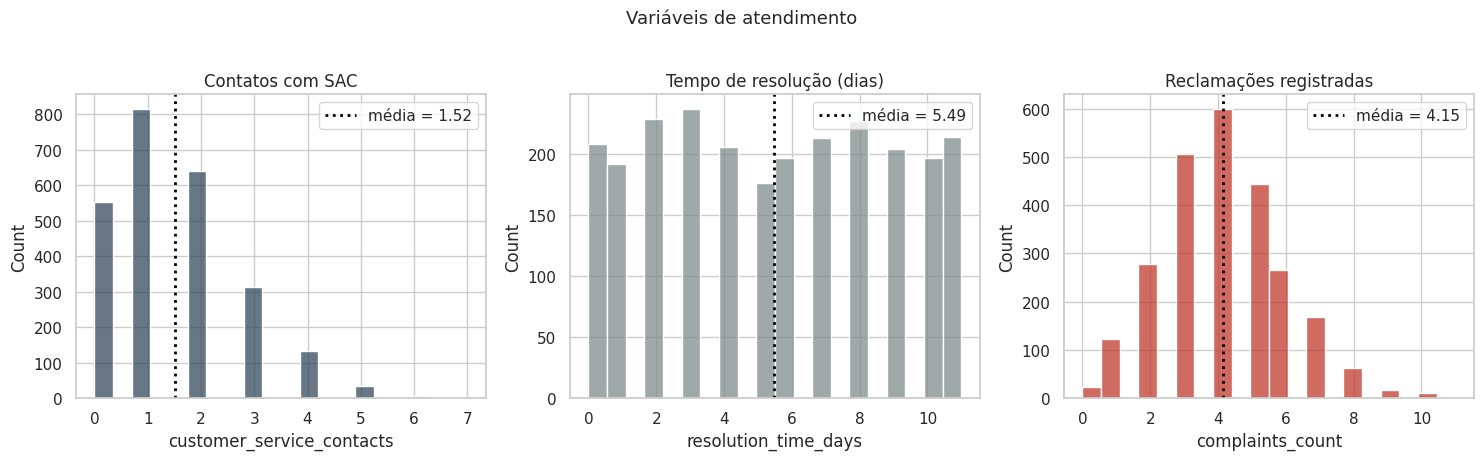

In [13]:
# Variáveis de atendimento
variaveis_atendimento = ["customer_service_contacts", "resolution_time_days", "complaints_count"]
print("Estatísticas descritivas — Atendimento:")
print(dados[variaveis_atendimento].describe().round(2).to_string())

# Grid 1x3 com linha de média
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))
configs = [
    ("customer_service_contacts", "Contatos com SAC",            "#34495e"),
    ("resolution_time_days",      "Tempo de resolução (dias)",   "#7f8c8d"),
    ("complaints_count",          "Reclamações registradas",     "#c0392b"),
]

for eixo, (col, titulo, cor) in zip(eixos, configs):
    sns.histplot(data=dados, x=col, bins=20, ax=eixo, color=cor, edgecolor="white")
    media = dados[col].mean()
    eixo.axvline(media, color="black", linestyle=":", linewidth=2, label=f"média = {media:.2f}")
    eixo.set_title(titulo)
    eixo.set_xlabel(col)
    eixo.legend()

fig.suptitle("Variáveis de atendimento", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_5_atendimento_distribuicoes.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuições das variáveis de atendimento (contatos, resolução, reclamações)](../reports/figures/02_data_understanding/2_5_atendimento_distribuicoes.png)

**Como ler este gráfico:** três histogramas em sequência, cada um para uma variável de atendimento. Em cada subplot, o eixo X é a contagem (de contatos, dias ou reclamações) e o eixo Y é o número de clientes. A **linha pontilhada preta vertical** marca a média.

As três variáveis de atendimento confirmam o quadro de empresa em situação ruim.

O `customer_service_contacts` vai de 0 a 7, com mediana 1 e média 1,52. Algumas observações importantes: o quartil superior tem 2 contatos, e o cliente "típico" entrou em contato uma vez. Cliente com zero contatos existe, mas não é a maioria, o que enfraquece um pouco a hipótese H6 (detrator silencioso) na sua versão mais forte: parece que a maioria dos clientes desta base está reclamando ativamente. Isso vai precisar ser investigado em mais detalhe na EDA.

O `resolution_time_days` vai de 0 a 11 dias, com mediana 6 e média 5,49. Resolver um problema em 6 dias é considerado lento para padrões atuais de e-commerce, onde a expectativa do cliente é resposta em até 24-48 horas. Aqui há uma variável que provavelmente vai aparecer como forte preditora de detração na modelagem.

O `complaints_count` é o achado mais surpreendente desta área: varia de 0 a 11 reclamações, com **mediana 4 e média 4,15**. O cliente típico fez quatro reclamações formais. Isso é fora do padrão de qualquer e-commerce real (onde a média seria abaixo de 1). Reforça mais uma vez a leitura de dataset sintético com cenário deliberadamente difícil. Para a análise, isso é uma vantagem: a variável tem variância suficiente para sair como preditora relevante no modelo.

Estatísticas descritivas — Indicadores:
       csat_internal_score  repeat_purchase_30d
count             2500.000             2500.000
mean                 2.942                0.087
std                  2.379                0.282
min                  0.000                0.000
25%                  0.700                0.000
50%                  2.800                0.000
75%                  4.800                0.000
max                 10.000                1.000


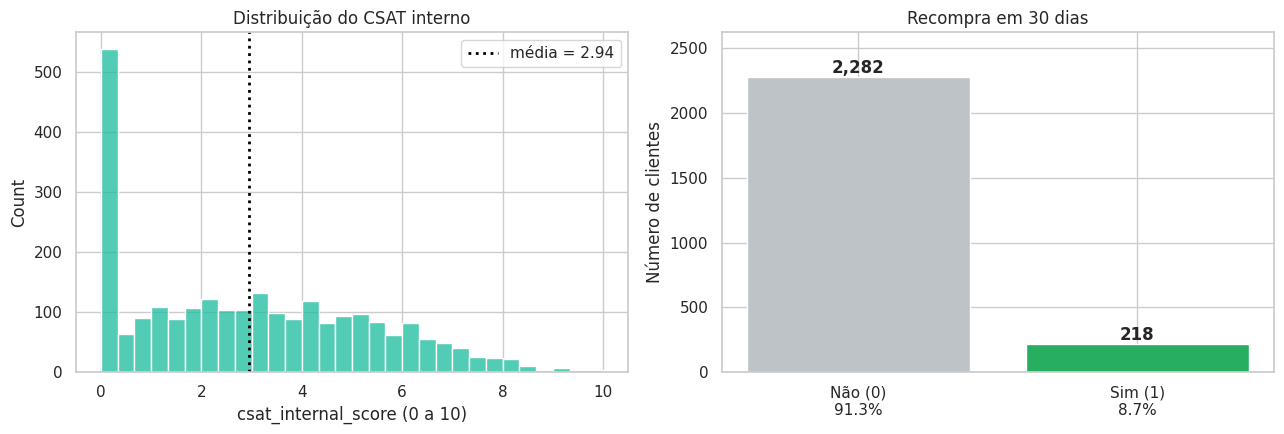

In [14]:
# Indicadores internos (não-target)
variaveis_indicadores = ["csat_internal_score", "repeat_purchase_30d"]
print("Estatísticas descritivas — Indicadores:")
print(dados[variaveis_indicadores].describe().round(3).to_string())

# CSAT como histograma (com média); repeat_purchase_30d como bar (binária, sem média)
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=dados, x="csat_internal_score", bins=30, ax=eixos[0], color="#1abc9c", edgecolor="white")
media_csat = dados["csat_internal_score"].mean()
eixos[0].axvline(media_csat, color="black", linestyle=":", linewidth=2, label=f"média = {media_csat:.2f}")
eixos[0].set_title("Distribuição do CSAT interno")
eixos[0].set_xlabel("csat_internal_score (0 a 10)")
eixos[0].legend()

contagem_recompra = dados["repeat_purchase_30d"].value_counts().sort_index()
percentual_recompra = (contagem_recompra / len(dados) * 100).round(1)
labels_recompra = [f"Não (0)\n{percentual_recompra[0]}%", f"Sim (1)\n{percentual_recompra[1]}%"]
eixos[1].bar(labels_recompra, contagem_recompra.values, color=["#bdc3c7", "#27ae60"], edgecolor="white")
for i, v in enumerate(contagem_recompra.values):
    eixos[1].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")
eixos[1].set_title("Recompra em 30 dias")
eixos[1].set_ylabel("Número de clientes")
eixos[1].set_ylim(0, contagem_recompra.max() * 1.15)

fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_5_indicadores_distribuicoes.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuições do CSAT interno e da taxa de recompra em 30 dias](../reports/figures/02_data_understanding/2_5_indicadores_distribuicoes.png)

**Como ler este gráfico:** dois painéis. À esquerda, histograma do CSAT interno com **linha pontilhada na média**. À direita, bar chart binário do `repeat_purchase_30d`: as duas barras mostram quantos clientes recompraram (1) versus não recompraram (0), com o percentual abaixo de cada rótulo.

Os dois indicadores confirmam o cenário difícil que vimos na target.

O `csat_internal_score` tem média 2,94 e mediana 2,80, em uma escala de 0 a 10. Ou seja, o CSAT interno também é baixíssimo, alinhado ao NPS de -80 que vimos na 2.3. Isso reduz, em parte, a preocupação de target leakage: se o CSAT está sistematicamente igualmente baixo, ele não está "trapaceando" muito, é só mais um termômetro confirmando o quadro. Ainda vamos rodar o modelo com e sem ele no notebook 03 para confirmar.

O `repeat_purchase_30d` tem 91,3% de zeros (não recomprou) e 8,7% de uns (recomprou). É forte desbalanceamento, mas faz sentido dada a base de detratores: se 84% dos clientes detrataram, é natural que poucos tenham voltado a comprar. Para a hipótese H5 (NPS prediz recompra), esses 8,7% de recompradores são exatamente o grupo onde vamos olhar se NPS alto se converteu em comportamento.

Encerrando a 2.5: nenhuma variável apresentou problemas técnicos (range fora do esperado, valores impossíveis, distribuições degeneradas). Todas estão usáveis como entrada para a modelagem. Os pontos de atenção que ficam para o notebook 03 (data preparation) são: (1) potencial transformação de variáveis assimétricas (`order_value`, `discount_value`) e (2) o tratamento do `csat_internal_score` (incluir vs. excluir).

## 2.6 Perfil das variáveis categóricas

Restam apenas duas variáveis categóricas no dataset: `customer_region`, com cinco regiões do Brasil, e `repeat_purchase_30d`, que é binária e já apareceu na seção 2.5. Aqui o foco é entender como os clientes se distribuem entre as regiões e o que isso pode significar para a análise.

Clientes por região:
  Sul          :   521 clientes (20.8%)
  Sudeste      :   520 clientes (20.8%)
  Norte        :   506 clientes (20.2%)
  Nordeste     :   485 clientes (19.4%)
  Centro-Oeste :   468 clientes (18.7%)


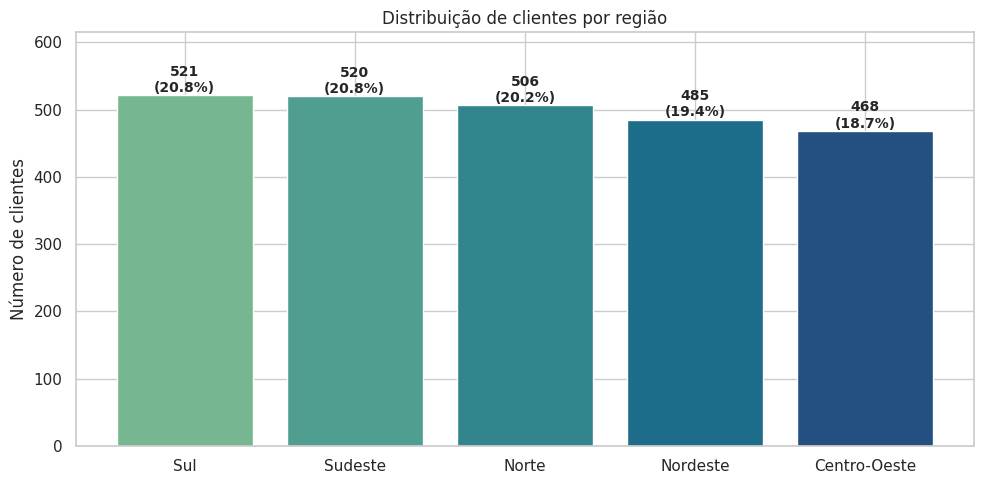

In [15]:
# Distribuição da região
contagem_regiao = dados["customer_region"].value_counts()
percentual_regiao = (contagem_regiao / len(dados) * 100).round(1)

print("Clientes por região:")
for regiao, n in contagem_regiao.items():
    print(f"  {regiao:13s}: {n:5,} clientes ({percentual_regiao[regiao]}%)")

# Bar chart com as 5 regiões
fig, eixo = plt.subplots(figsize=(10, 5))
cores_regioes = sns.color_palette("crest", n_colors=len(contagem_regiao))
barras = eixo.bar(contagem_regiao.index, contagem_regiao.values, color=cores_regioes, edgecolor="white")

for i, (regiao, valor) in enumerate(contagem_regiao.items()):
    eixo.text(i, valor + 5, f"{valor:,}\n({percentual_regiao[regiao]}%)",
              ha="center", fontsize=10, fontweight="bold")

eixo.set_title("Distribuição de clientes por região")
eixo.set_ylabel("Número de clientes")
eixo.set_ylim(0, contagem_regiao.max() * 1.18)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_6_distribuicao_regioes.png", dpi=120, bbox_inches="tight")
plt.show()

![Distribuição de clientes por região do Brasil](../reports/figures/02_data_understanding/2_6_distribuicao_regioes.png)

**Como ler este gráfico:** cada barra representa uma das cinco regiões do Brasil presentes no dataset. A altura da barra é o número absoluto de clientes daquela região; o percentual da base aparece logo acima de cada barra entre parênteses. Quanto mais parecidas as alturas das barras, mais uniforme é a distribuição entre regiões.

A distribuição entre as cinco regiões é praticamente uniforme: a região mais representada (Sul, com 521 clientes) tem apenas 11% a mais que a menos representada (Centro-Oeste, com 468). Cada região concentra entre 18,7% e 20,8% da base.

Esse equilíbrio é irrealista para um e-commerce brasileiro real. Em dados reais, o Sudeste tipicamente concentra entre 50% e 65% das compras online, seguido pelo Sul (15-20%) e Nordeste (10-15%), com Norte e Centro-Oeste com participação bem menor. A distribuição uniforme observada aqui é mais um indicativo de que o dataset foi gerado de forma sintética, com clientes sorteados igualmente entre as cinco regiões.

Para a análise, essa característica tem duas implicações.

A primeira é positiva para a estatística: como temos volume comparável em cada região (entre 468 e 521 observações), comparações entre regiões vão ter poder estatístico equivalente em todas elas. Em base real, conclusões sobre Norte ou Centro-Oeste teriam intervalos de confiança bem maiores por causa do volume menor.

A segunda é uma limitação para a hipótese H7 (NPS varia por região por causa de fatores operacionais, não culturais). Como os dados foram gerados sinteticamente, qualquer efeito de região que aparecer no modelo provavelmente reflete a forma como o gerador de dados associou variáveis às regiões, e não um padrão real de comportamento regional. Isso não impede testar a hipótese, mas significa que conclusões sobre região no slide executivo precisam ser apresentadas com cuidado, marcadas como exercício metodológico e não como diagnóstico de mercado real.

## 2.7 Sinais visuais — boxplots e preview da EDA

Os histogramas da seção 2.5 mostraram a forma das distribuições, mas tem coisa que histograma não revela bem: a presença de outliers individuais e a relação visual entre quartis. Boxplot é a ferramenta certa para isso. Esta seção tem dois objetivos: (1) confirmar via boxplot que não há outliers que precisem de tratamento agora, e (2) dar um preview rápido de como algumas variáveis-chave se comportam quando segmentadas pelo bucket do NPS, antecipando o que vamos investigar a fundo na EDA do notebook 04.

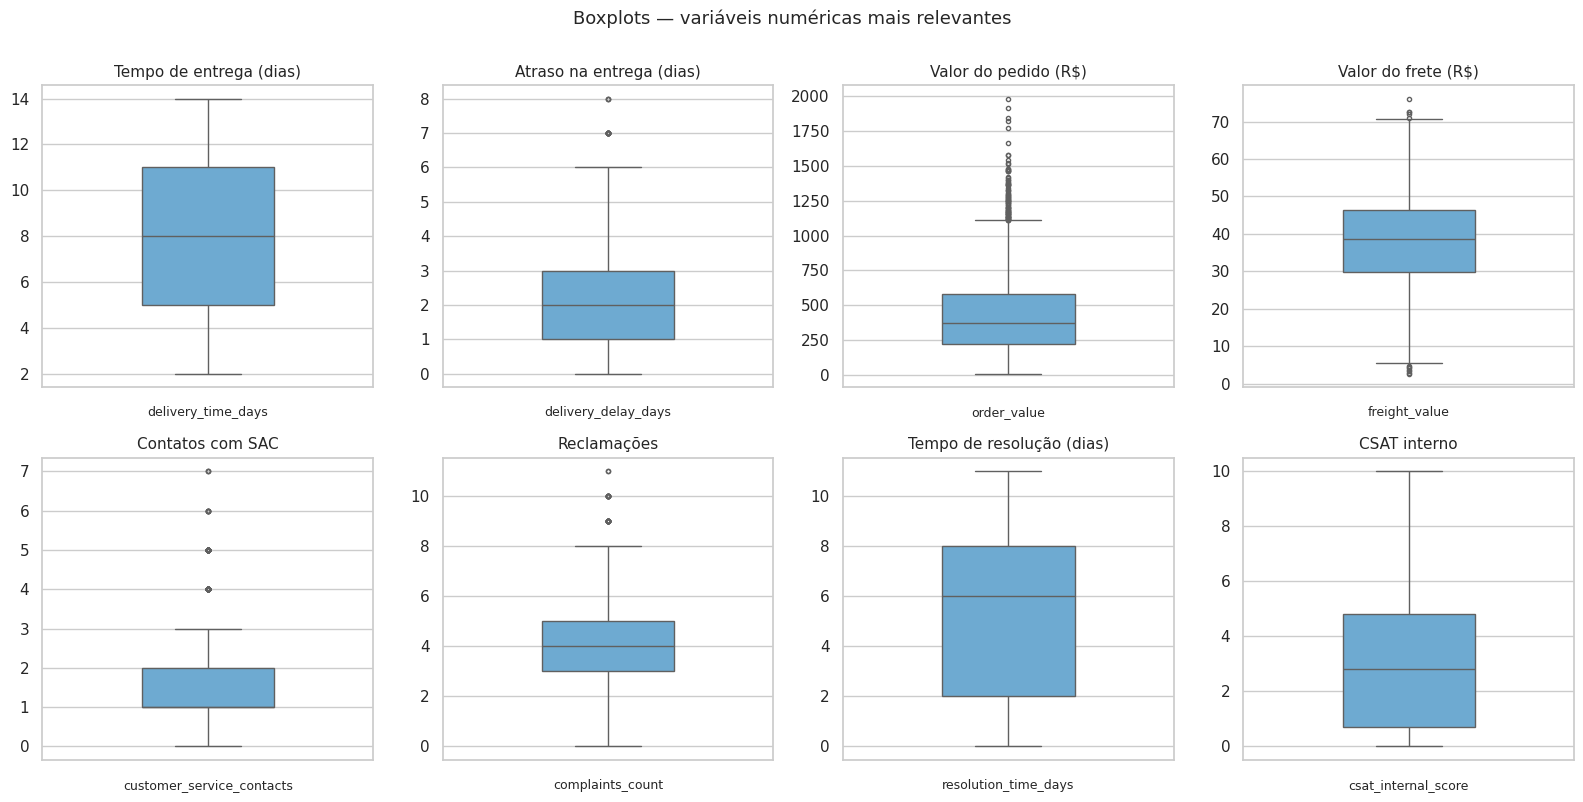

In [16]:
# Grid 2x4 de boxplots das variáveis numéricas mais relevantes para a análise
variaveis_boxplot = [
    ("delivery_time_days",        "Tempo de entrega (dias)"),
    ("delivery_delay_days",       "Atraso na entrega (dias)"),
    ("order_value",               "Valor do pedido (R$)"),
    ("freight_value",             "Valor do frete (R$)"),
    ("customer_service_contacts", "Contatos com SAC"),
    ("complaints_count",          "Reclamações"),
    ("resolution_time_days",      "Tempo de resolução (dias)"),
    ("csat_internal_score",       "CSAT interno"),
]

fig, eixos = plt.subplots(2, 4, figsize=(16, 8))
for eixo, (col, titulo) in zip(eixos.flat, variaveis_boxplot):
    sns.boxplot(data=dados, y=col, ax=eixo, color="#5dade2", width=0.4, fliersize=3)
    eixo.set_title(titulo, fontsize=11)
    eixo.set_ylabel("")
    eixo.set_xlabel(col, fontsize=9)

fig.suptitle("Boxplots — variáveis numéricas mais relevantes", fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_7_boxplots_variaveis_chave.png", dpi=120, bbox_inches="tight")
plt.show()

![Boxplots das variáveis numéricas mais relevantes](../reports/figures/02_data_understanding/2_7_boxplots_variaveis_chave.png)

**Como ler este gráfico:** cada um dos oito painéis é um **boxplot** vertical de uma variável diferente. A **caixa** mostra o intervalo entre o primeiro quartil (Q1, 25% dos dados abaixo) e o terceiro quartil (Q3, 75% abaixo). A **linha horizontal dentro da caixa** é a mediana. Os **"bigodes"** acima e abaixo da caixa estendem o range típico (até 1,5 vezes o intervalo interquartil). **Pontos fora dos bigodes** são considerados outliers no critério estatístico, mas podem ser valores reais e plausíveis, não erros.

Os boxplots confirmam o que já vimos nos histogramas e adicionam algumas observações.

A maioria das variáveis está bem-comportada: as caixas (quartis 25-75) estão centradas e os "bigodes" se estendem de forma simétrica ou levemente assimétrica. Não há outliers extremos que justifiquem tratamento via remoção ou capping no notebook 03.

Algumas observações pontuais:

- **`order_value`** tem alguns pontos acima do bigode superior. São pedidos de ticket alto (acima de aproximadamente R$ 1.200), mas todos parecem plausíveis (até cerca de R$ 2.000) e são poucos. Não são outliers no sentido estatístico de "valores impossíveis": são clientes com pedidos maiores, que vamos querer manter na base porque a hipótese H2 diz exatamente que esses clientes podem ter tolerância diferente a atrasos.

- **`customer_service_contacts`** mostra alguns pontos acima de 4-5 contatos. Também são clientes reais, e provavelmente os mais próximos do estado de "abandono" da relação. Vamos investigar esses casos na EDA.

- **`complaints_count`** tem cauda longa até 11 reclamações, o que reforça a observação da 2.5 de que esta variável está com comportamento bem fora do padrão de e-commerce real (mediana 4 já é alta).

Nenhuma variável tem comportamento que indique problema de qualidade do dado.

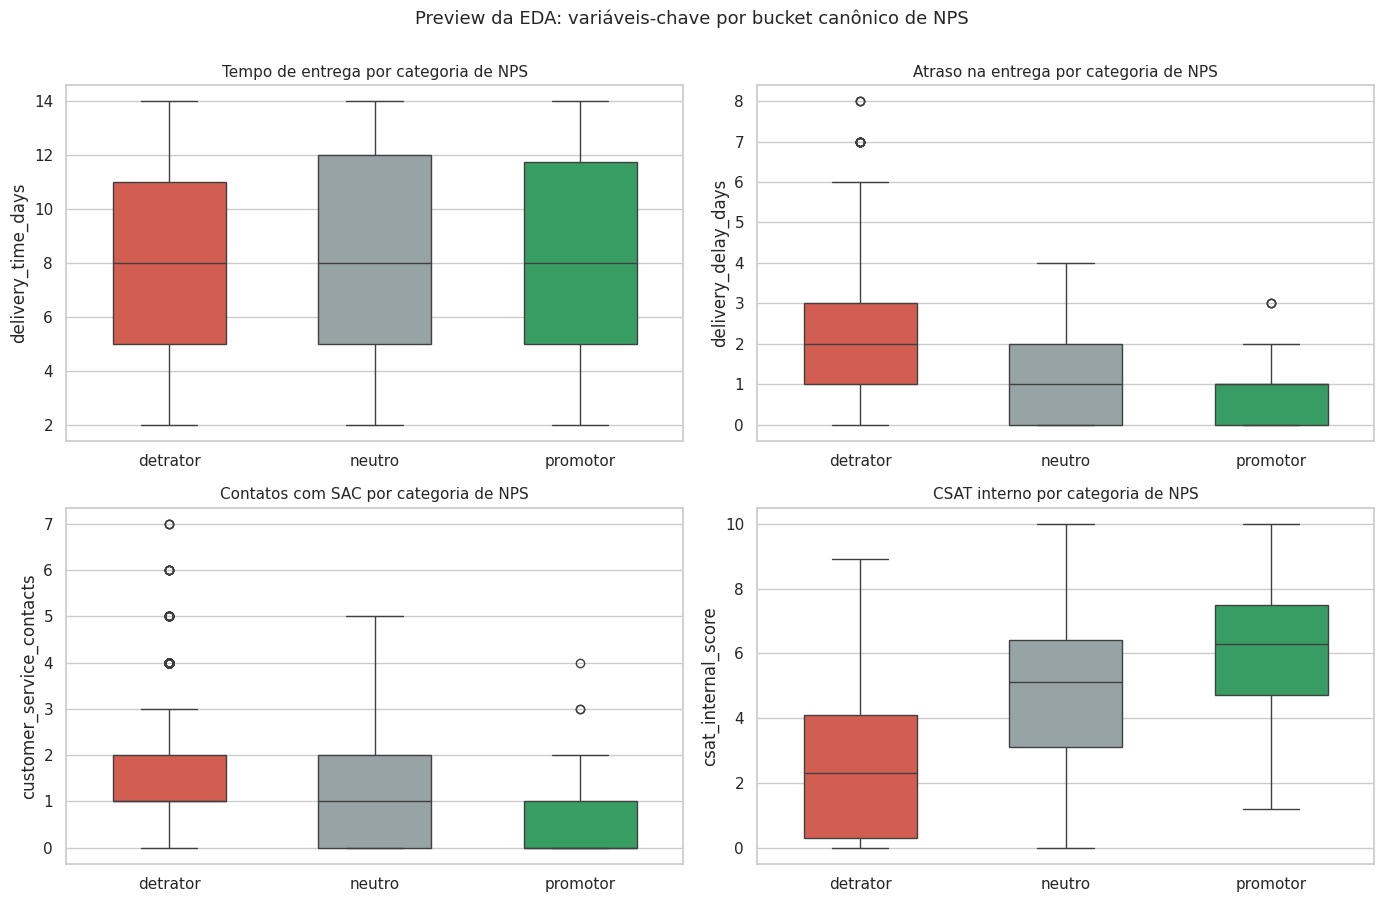

In [17]:
# Preview de relação com a target: boxplot de variáveis-chave por bucket de NPS
# Reusa a categorização canônica e as cores semânticas

def classificar_nps(nota: float) -> str:
    if nota < 7:
        return "detrator"
    elif nota < 9:
        return "neutro"
    else:
        return "promotor"

dados_preview = dados.assign(categoria_nps=dados["nps_score"].apply(classificar_nps))
ordem_buckets = ["detrator", "neutro", "promotor"]
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}

variaveis_chave = [
    ("delivery_time_days",        "Tempo de entrega por categoria de NPS"),
    ("delivery_delay_days",       "Atraso na entrega por categoria de NPS"),
    ("customer_service_contacts", "Contatos com SAC por categoria de NPS"),
    ("csat_internal_score",       "CSAT interno por categoria de NPS"),
]

fig, eixos = plt.subplots(2, 2, figsize=(14, 9))
for eixo, (col, titulo) in zip(eixos.flat, variaveis_chave):
    sns.boxplot(
        data=dados_preview,
        x="categoria_nps",
        y=col,
        order=ordem_buckets,
        palette=[cores_buckets[c] for c in ordem_buckets],
        ax=eixo,
        width=0.55,
        hue="categoria_nps",
        legend=False,
    )
    eixo.set_title(titulo, fontsize=11)
    eixo.set_xlabel("")
    eixo.set_ylabel(col)

fig.suptitle("Preview da EDA: variáveis-chave por bucket canônico de NPS", fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "2_7_preview_variaveis_por_categoria_nps.png", dpi=120, bbox_inches="tight")
plt.show()

![Preview da EDA: variáveis-chave por bucket canônico de NPS](../reports/figures/02_data_understanding/2_7_preview_variaveis_por_categoria_nps.png)

**Como ler este gráfico:** quatro painéis, um para cada variável-chave. Em cada painel, **três boxplots verticais lado a lado** mostram a distribuição da variável separada pelas três categorias de NPS. As cores são semânticas (**vermelho = detrator, cinza = neutro, verde = promotor**). Quanto mais altas as caixas vermelhas em relação às verdes, mais a variável tende a estar associada a clientes detratores.

Esse preview já dá pistas fortes do que vamos confirmar na EDA do notebook 04.

**`delivery_time_days` (tempo de entrega):** detratores e neutros parecem ter tempo de entrega levemente maior do que promotores, mas a diferença visual é discreta. A mediana de cada grupo está próxima de 8 dias. Pode ser que o efeito de tempo de entrega seja menor do que a intuição sugere, ou que ele só apareça em interação com outras variáveis (como o ponto de ruptura proposto na hipótese H1).

**`delivery_delay_days` (atraso):** aqui já se vê uma separação mais clara. A caixa dos detratores está visivelmente mais alta, indicando que clientes detratores tiveram atrasos maiores do que neutros e promotores. É a primeira pista visual de que H1 e H2 (hipóteses de logística) provavelmente vão se confirmar na análise estatística.

**`customer_service_contacts` (contatos com SAC):** padrão semelhante, com detratores tendo mediana mais alta. Reforça que clientes que mais contataram o SAC tendem a estar entre os mais insatisfeitos, mas como já discutido na 1.7, isso pode ser sintoma e não causa.

**`csat_internal_score` (CSAT interno):** essa é a separação mais brutal. Detratores têm CSAT centrado em torno de 2-3, neutros em torno de 5, promotores acima de 7. Como suspeitamos na 2.4, o CSAT interno se move bastante na mesma direção do NPS, o que faz dele simultaneamente um indicador útil e um candidato a target leakage no modelo. A decisão de incluir ou não essa variável vai depender de quão bem os outros preditores conseguem reproduzir esse sinal sozinhos, e disso vamos cuidar no notebook 03.

Esses padrões visuais são apenas indícios. Confirmação estatística (testes de hipóteses, intervalos de confiança, regressão) fica para a EDA aprofundada e para a fase de modelagem.

## 2.8 Viabilidade das 7 hipóteses

Com o que vimos sobre os dados, vale revisitar uma a uma as sete hipóteses formuladas no notebook 01, classificando cada uma por status (viável sem ajuste, viável com ajuste, ou comprometida) e justificando com os achados desta fase.

### H1 — Ponto de ruptura em `delivery_time_days`

**Status: viável sem ajuste.** A variável tem variância suficiente (range 2 a 14 dias, mediana 8) e dá para criar buckets para investigar quebra de comportamento. O preview da 2.7 mostrou separação visual modesta entre os grupos de NPS, mas isso é esperado: pontos de ruptura raramente aparecem em boxplot agregado, e sim na análise por faixas. Vamos seguir com essa hipótese intacta para a EDA.

### H2 — Tolerância a atraso depende do valor do pedido

**Status: viável sem ajuste.** Tanto `order_value` (R$ 7,76 a R$ 1.983,81) quanto `delivery_delay_days` (0 a 8 dias) têm variância suficiente para suportar análise de interação. O preview mostrou que detratores tiveram atraso visivelmente maior, o que é o ingrediente básico de qualquer interação. Termo de interação na regressão linear deve sair significativo.

### H3 — Service Recovery Paradox

**Status: viável com ajuste.** A hipótese pressupõe três grupos: quem não reclamou, quem reclamou e foi resolvido rápido, quem reclamou e foi resolvido devagar. O problema é que a 2.5 mostrou que `complaints_count` tem **mediana 4** — quase ninguém na base "não reclamou". O grupo "não reclamou" provavelmente é pequeno demais para sustentar comparação. Vamos precisar reformular a hipótese trabalhando com **graus de reclamação** (poucas vs. muitas), em vez do recorte binário "reclamou vs. não reclamou".

### H4 — Blind spots entre `csat_internal_score` e `nps_score`

**Status: viável com ajuste.** O preview da 2.7 mostrou que CSAT e NPS movem juntos fortemente (separação clara entre detratores, neutros e promotores em ambos). Isso significa que o gap "CSAT alto e NPS baixo", que daria os blind spots procurados, deve ser raro. A hipótese continua testável, mas o resultado provável é "blind spots existem em pequena minoria". Vamos olhar a distribuição do gap e segmentar os casos extremos, mesmo que sejam poucos.

### H5 — NPS prediz `repeat_purchase_30d`

**Status: viável sem ajuste.** A variável de recompra tem 91,3% de zeros e 8,7% de uns. Os 217 clientes que recompraram são suficientes para teste de proporções entre buckets de NPS. A hipótese deve sair confirmada, dado o desbalanceamento natural (poucos promotores na base, mas a expectativa é que esses poucos se concentrem nos recompradores).

### H6 — Detrator silencioso

**Status: viável com ajuste.** A hipótese era que clientes com zero contatos com SAC poderiam ser detratores que desistiram de reclamar. Mas a 2.5 mostrou que `customer_service_contacts` tem mediana 1 e bem poucos têm exatamente 0 contatos. O grupo que sustenta a hipótese é pequeno. Vamos olhar a distribuição de NPS para esse grupo "zero contatos" mesmo assim, mas o resultado pode ser inconclusivo por baixo volume.

### H7 — Variação de NPS por região é operacional, não regional

**Status: comprometida (não invalidada), mas continua testável.** A 2.6 mostrou que as cinco regiões estão equilibradas demais para serem dados reais (diferença de apenas 11% entre a maior e a menor). Isso é evidência de geração sintética. Mecanicamente a hipótese ainda funciona: dá para rodar regressão com e sem `customer_region` e ver se o efeito da região diminui quando controlamos pelas operacionais. Mas conclusões sobre **Brasil real** ficam limitadas. Vamos seguir com essa hipótese deixando a ressalva clara nos slides executivos.

### Resumo do status

| Hipótese | Status |
|---|---|
| H1 — Ponto de ruptura em `delivery_time_days` | Viável sem ajuste |
| H2 — Interação `order_value` × `delivery_delay_days` | Viável sem ajuste |
| H3 — Service Recovery Paradox | Viável com ajuste |
| H4 — Blind spots CSAT vs. NPS | Viável com ajuste |
| H5 — NPS prediz recompra | Viável sem ajuste |
| H6 — Detrator silencioso | Viável com ajuste |
| H7 — Região explicada por operacional | Comprometida (sintético), mas testável |

Cinco hipóteses seguem fortes, três precisam de ajuste de definição, e nenhuma foi descartada. O notebook 03 vai cuidar das transformações necessárias para deixar o dataset pronto para a EDA aprofundada.

## 2.9 Conclusão da fase

O dataset é viável para o trabalho. Os pontos consolidados desta fase, em ordem de relevância:

- **Granularidade simples:** linha = pedido = cliente único. Sem agregação necessária.
- **Qualidade técnica perfeita demais:** zero missing, zero duplicata, tipos coerentes. Tipico de dataset sintético/acadêmico.
- **Target em escala incomum:** `nps_score` em float (0.0 a 10.0 em passos de 0.1), com **NPS bruto -80** que é catastroficamente baixo para benchmark real. Vamos seguir, mas as conclusões absolutas precisam de ressalva.
- **Desbalanceamento severo na target:** 84,4% detratores, 11,2% neutros, 4,4% promotores. Vai pesar na fase de classificação.
- **Atrasos onipresentes:** mediana 2 dias de `delivery_delay_days`, ou seja, praticamente todo cliente teve algum atraso. O dataset foi construído para fazer essa variável pesar.
- **CSAT interno também muito baixo:** mediana 2,8 em escala 0-10, alinhado ao NPS. Reduz parcialmente a preocupação de target leakage, mas vamos rodar o modelo com e sem `csat_internal_score` no notebook 03.
- **Distribuição regional uniforme:** irrealista, mas vantajosa para poder estatístico.

### O que vai para o notebook 03 (Data Preparation)

A próxima fase do CRISP-DM é a preparação dos dados. As decisões já tomadas a partir do que aprendemos aqui:

1. **Categorização explícita do `nps_score`** em três níveis (detrator, neutro, promotor), criando uma coluna nova ao lado do score contínuo. Vamos precisar das duas representações para regressão e classificação.
2. **Conversão da `customer_region` para tipo categórico** (`pd.Categorical`), economizando memória e padronizando comparações.
3. **Geração de variável binária para a hipótese H5** (alta_recompra_30d, mais explícita que `repeat_purchase_30d`).
4. **Avaliação de transformação log** para variáveis com cauda à direita (`order_value`, `discount_value`), caso isso melhore a linearidade na regressão.
5. **Estratégia para o `csat_internal_score`:** manter a coluna no dataset processado, mas treinar dois modelos paralelos (com e sem ela) na fase de modelagem para medir o impacto de target leakage.
6. **Sem imputação** (não há missing) e **sem remoção de outliers** (os pontos fora do bigode nos boxplots da 2.7 são valores plausíveis, não erros de coleta).

A próxima fase fecha a preparação e nos deixa pronto para a EDA aprofundada do notebook 04, onde as sete hipóteses vão ser testadas estatisticamente com as técnicas vistas em aula (testes de hipóteses, intervalos de confiança, regressão linear).